In [ ]:
# --timeframe 1d   : Таймфрейм свечей (дневные данные).
# --start-year 2000: Глубина загрузки истории (начиная с 2000 года).
# --workers 6      : Количество параллельных потоков для ускорения загрузки.

!python -m _tools.update_market_data --timeframe 1d --start-year 2000 --workers 18
!python -m _tools.update_macro --timeframe 1d --start-year 2000 --workers 18
# Выполняет комплексную проверку целостности, отсутствия пропусков и корректности OHLCV данных.
!python -m _tools.check_data_quality

In [ ]:
# --timeframe 1d       : Интервал данных — дневные свечи.
# --lookback 60        : Глубина истории — модель смотрит на 60 дней назад.
# --horizon 10         : Горизонт прогноза — ищем выход по барьерам в течение 10 дней.
# --auto               : Режим автоматического расчета уровней TP/SL на основе волатильности.
# --percentile 75      : Перцентиль волатильности для отсечения аномальных выбросов при авто-разметке.
# --init_split         : Дата начала первого разделения данных на Train и Val.
# --val_interval 2     : Продолжительность валидационного периода в годах.
# --split_interval 2   : Шаг смещения окна Walk-Forward в годах.
# --endpoint           : Дата окончания формирования всех временных интервалов.
# --corr_threshold     : Порог удаления коррелирующих признаков (убираем дубликаты > 85%).
# --cum_threshold      : Порог кумулятивной важности (оставляем топ фичей, дающих 99% влияния).
# --force              : Раскомментируйте параметр ниже для полной перезаписи кэшированных данных.

!python -m _tools.init_dataset \
    --timeframe 1d \
    --lookback 10 \
    --horizon 5 \
    --auto \
    --percentile 75 \
    --init_split 2010-01-01 \
    --val_interval 2 \
    --split_interval 2 \
    --endpoint 2024-01-01 \
    --corr_threshold 0.85 \
    --cum_threshold 0.99

In [ ]:
#полная проверка подготовленных на предыдущем этапе данных
!python -m _tools.verify_data

In [ ]:
import os
import shutil
from pathlib import Path

# ⚠️ ВНИМАНИЕ: Укажи точный путь к нужной конфигурации
DATASET_DIR = Path("data/processed/2000_2026_1d_90_15")

def clean_configuration(dataset_path):
    if not dataset_path.exists():
        print(f"❌ Директория {dataset_path} не найдена!")
        return

    folds = sorted([d for d in dataset_path.glob("fold_*") if d.is_dir()])
    print(f"🔍 Найдено фолдов: {len(folds)}. Начинаю тотальную очистку конфигурации...\n")
    
    total_deleted_files = 0
    
    for fold in folds:
        print(f"📂 Очистка {fold.name}...")
        
        # 1. Удаляем все модели и их метаданные (.keras, .json, .h5)
        models_dir = fold / "models"
        if models_dir.exists():
            shutil.rmtree(models_dir)
            models_dir.mkdir(parents=True, exist_ok=True) # Создаем пустую папку обратно
            print("   ✅ Папка models/ полностью очищена.")
            
        # 2. Удаляем базы данных (Оркестратор + Optuna + временные файлы SQLite)
        db_files = [
            "trading_factory.db", "trading_factory.db-shm", "trading_factory.db-wal",
            "optuna_study.db", "optuna_study.db-shm", "optuna_study.db-wal"
        ]
        for db_name in db_files:
            db_path = fold / db_name
            if db_path.exists():
                db_path.unlink()
                print(f"   ✅ База данных {db_name} удалена.")
                total_deleted_files += 1
                
        # 3. Удаляем кэш батча и замки (для чистой рекалибровки VRAM)
        artifacts_dir = fold / "artifacts"
        if artifacts_dir.exists():
            for file_to_delete in ["batch_config.json", "batch_calc.lock"]:
                file_path = artifacts_dir / file_to_delete
                if file_path.exists():
                    file_path.unlink()
                    print(f"   ✅ Файл {file_to_delete} удален.")
        print("-" * 40)
                    
    print(f"🎉 Очистка успешно завершена! Конфигурация {dataset_path.name} готова к чистому старту.")

# Запуск
clean_configuration(DATASET_DIR)

In [ ]:
!python -m _tools.train_ltsm_model \
    --dataset_dir "data/processed/2000_2026_1d_90_15" \
    --fold "fold_2014" \
    --init_pca_coord -100.0 120.0 \
    --init_pca_radius 15.0 \
    --runs 500 --epochs 50 \
    --append

In [ ]:
#Запуск нескольких процессов в параллели
!bash start_swarm.sh \
    --dataset_dir "data/processed/2000_2026_1d_6_1" \
    --bonus_ratio 0.2 \
    --min_delta 0.001 \
    --runs 300 --epochs 100 \
    --lr 2e-3 --l2_reg 1e-5 \
    --start_fold "fold_2010" \
    --factor 0.5 --patience 5 \
    --vram 1200 --stagger 0 \
    --append \
    --arch conv1d+gru
    #--arch conv1d+gru, cnn, mlp
    #--track_trajectory
    #--init_pca_coord -148.0 -116.0 --init_pca_radius 20.0 \

In [ ]:
!./stop_swarm.sh
!python -m _tools.clean_lstm_models --keep 5

In [3]:
!python -m _tools.ensemble_predictor --dataset_dir data/processed/2000_2026_1d_6_1 --fold fold_2012 --max_k 15

I0000 00:00:1779979746.211799    3593 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779979747.300153    3593 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
🚀 Запуск КОМБИНАТОРНОГО Ансамблевого Анализатора (fold_2012)
📦 Загрузка валидационных данных...

🏆 Найдено 6 элитных моделей. Генерация предиктов...
  ⏳ Модель 1 (Indiv. Loss: 0.9083)...
  ⏳ Модель 2 (Indiv. Loss: 0.9086)...
  ⏳ Модель 3 (Indiv. Loss: 0.9089)...
  ⏳ Модель 4 (Indiv. Loss: 0.9091)...
  ⏳ Модель 5 (Indiv. Loss: 0.9099)...
  ⏳ Модель 6 (Indiv. Loss: 0.9100)...

🤝 Просчет всех возможных связок (63 комбинаций)...

Комбинац

In [ ]:
%run _tools/plot_landscape.py --fold data/processed/2000_2026_1d_30_5/fold_2014


📊 АНАЛИЗ ФОЛДА: fold_2020
🥇 Текущий абсолютный рекорд (Loss): 0.9320

🎯 Истинная макро-асимптота (Медиана): 0.9320
📊 Доверительный интервал (90%): от 0.9320 до 0.9341
⚖️ Ширина неопределенности: 0.00208

✅ ВЕРДИКТ: Оценка ПРАВДИВА. Веер сошелся, тренд железобетонный.
🟢 ОРКЕСТРАТОР: Можно продолжать (Рекорд еще не достиг медианной асимптоты).


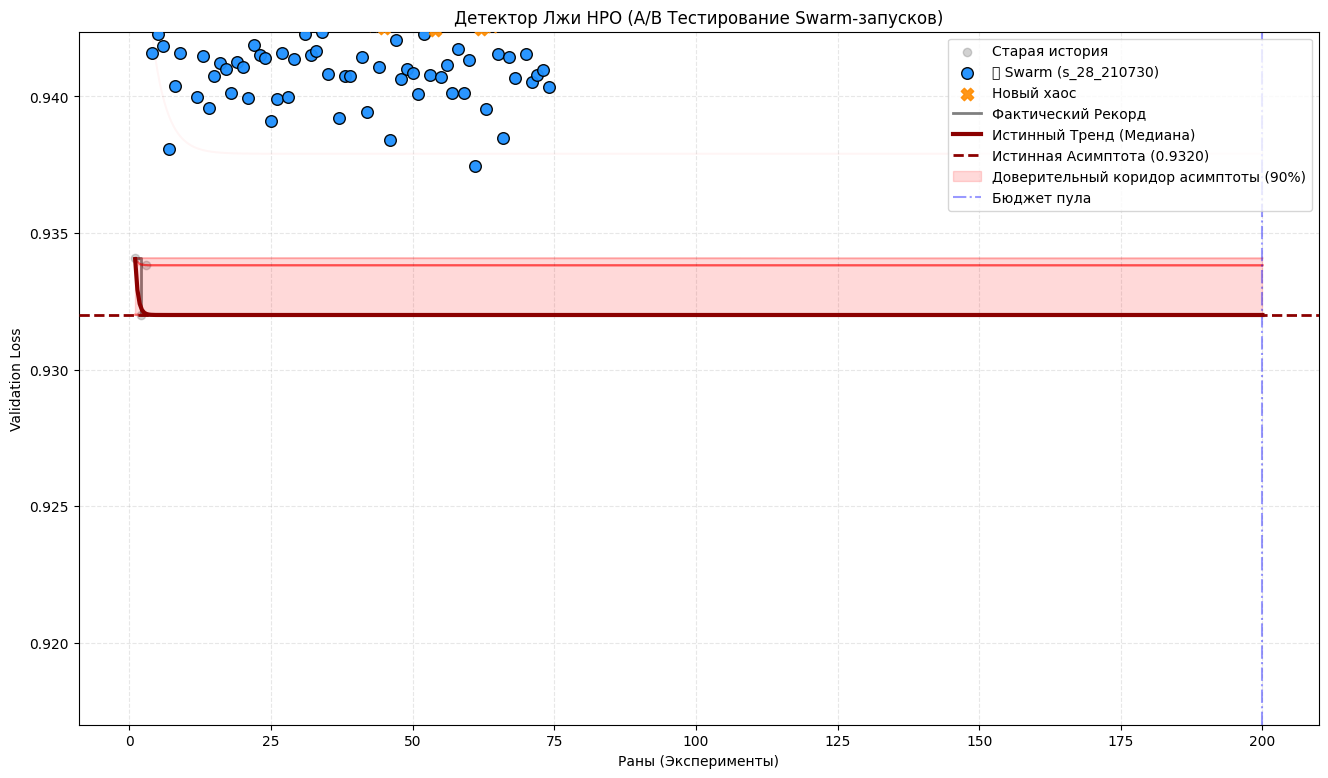

<Figure size 640x480 with 0 Axes>

In [18]:
%matplotlib inline
%run _tools/analyze_runs.py data/processed/2000_2026_1d_6_1/fold_2020 --runs 200

In [ ]:
!python -m _tools.prepare_rl_env

In [ ]:
!python -m _tools.check_env_data

In [ ]:
!python -m _tools.train_rllib_pbt --population 6 --iterations 3000 --force

⏳ Извлечение Топ-3 моделей из каждого фолда...
✅ Успешно загружено ранов: 162 (по 3 на каждый фолд)


,config,fold,loss_best,loss_mean,loss_var,acc_best,acc_mean,acc_var
0,2000_2026_1d_10_5,fold_2010,0.9080,0.9262,0.000309,0.7132,0.7109,0.000016
1,2000_2026_1d_10_5,fold_2012,0.9543,0.9550,0.000000,0.6010,0.5990,0.000003
2,2000_2026_1d_10_5,fold_2014,1.0120,1.0122,0.000000,0.5273,0.5246,0.000006
3,2000_2026_1d_10_5,fold_2016,0.9226,0.9235,0.000001,0.6288,0.6278,0.000002
4,2000_2026_1d_10_5,fold_2018,0.9475,0.9487,0.000001,0.6091,0.6080,0.000001
5,2000_2026_1d_10_5,fold_2020,0.9834,0.9849,0.000002,0.5467,0.5428,0.000034
6,2000_2026_1d_10_5,fold_2022,0.9931,0.9953,0.000003,0.5442,0.5388,0.000083
7,2000_2026_1d_10_5,fold_2024,0.9944,0.9955,0.000001,0.5378,0.5366,0.000001
8,2000_2026_1d_18_3,fold_2010,0.8488,0.8537,0.000031,0.7153,0.7079,0.000052
9,2000_2026_1d_18_3,fold_2012,0.9708,0.9716,0.000000,0.6056,0.6034,0.000005


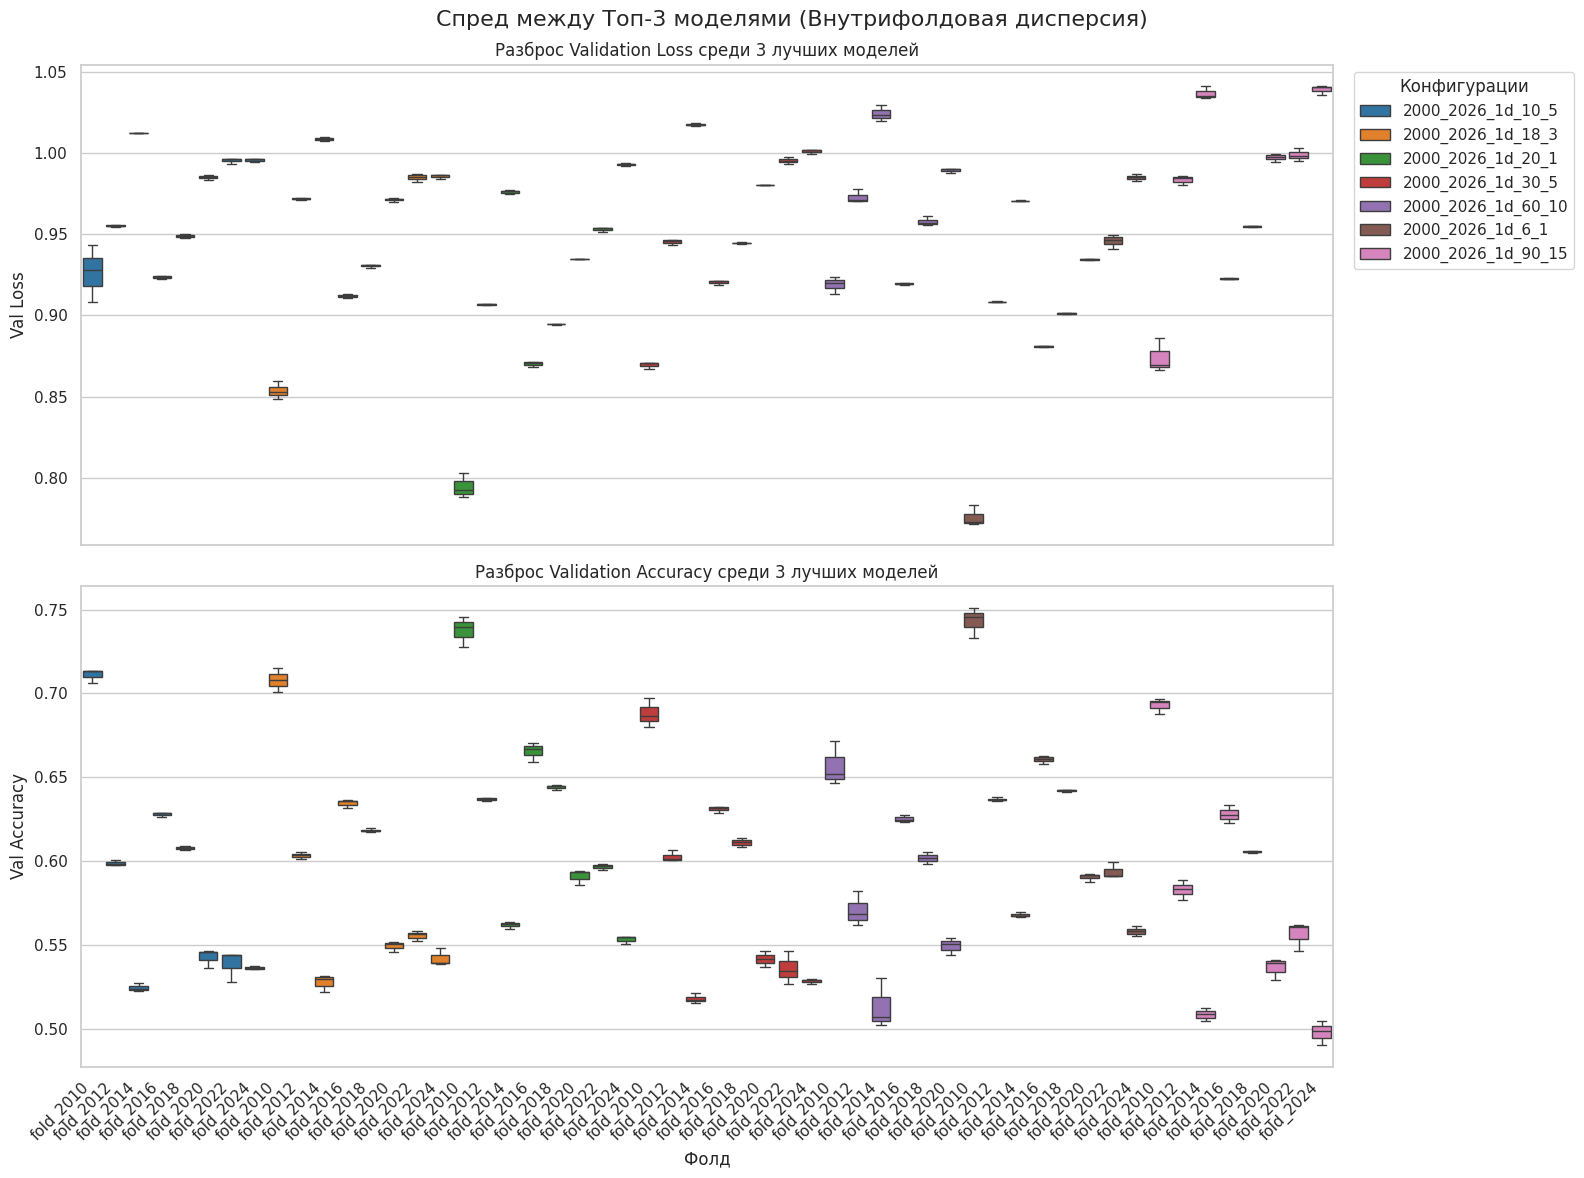

In [60]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Настройки графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

BASE_DIR = '/home/restorator/trader_test/data/processed'

def collect_top3_metrics(base_dir):
    """Сбор метрик ТОЛЬКО для 3 лучших моделей внутри каждого фолда"""
    all_top_runs = []
    
    if not os.path.exists(base_dir):
        print(f"❌ Директория не найдена: {base_dir}")
        return pd.DataFrame()

    for config_name in sorted(os.listdir(base_dir)):
        config_dir = os.path.join(base_dir, config_name)
        if not os.path.isdir(config_dir): continue
            
        for fold_name in sorted(os.listdir(config_dir)):
            fold_dir = os.path.join(config_dir, fold_name)
            db_path = os.path.join(fold_dir, 'trading_factory.db')
            
            if os.path.exists(db_path):
                try:
                    conn = sqlite3.connect(db_path)
                    # Вытягиваем ровно 3 лучших рана (те самые, что сохранены в .keras)
                    # Если твой ModelCheckpoint сохраняет по Accuracy, поменяй на: ORDER BY val_acc DESC
                    query = """
                        SELECT val_loss, val_acc 
                        FROM runs 
                        WHERE status='COMPLETED' 
                          AND val_loss IS NOT NULL 
                        ORDER BY val_loss ASC 
                        LIMIT 3
                    """
                    df = pd.read_sql_query(query, conn)
                    conn.close()
                    
                    if not df.empty:
                        df['config'] = config_name
                        df['fold'] = fold_name
                        all_top_runs.append(df)
                except Exception as e: 
                    print(f"Ошибка БД {fold_name}: {e}")
                    
    return pd.concat(all_top_runs, ignore_index=True) if all_top_runs else pd.DataFrame()

# 1. Сбор данных
print("⏳ Извлечение Топ-3 моделей из каждого фолда...")
df_top3 = collect_top3_metrics(BASE_DIR)

if df_top3.empty:
    print("❌ Данные не найдены.")
else:
    print(f"✅ Успешно загружено ранов: {len(df_top3)} (по 3 на каждый фолд)")
    
    # =================================================================
    # РАСЧЕТ СТАТИСТИКИ АНСАМБЛЯ (Спреда между 3 моделями)
    # =================================================================
    stats_df = df_top3.groupby(['config', 'fold']).agg(
        loss_best=('val_loss', 'min'),    # Лучший лосс из 3
        loss_mean=('val_loss', 'mean'),   # Средний лосс ансамбля
        loss_var=('val_loss', 'var'),     # Дисперсия внутри Топ-3
        acc_best=('val_acc', 'max'),      # Лучшая точность из 3
        acc_mean=('val_acc', 'mean'),     # Средняя точность ансамбля
        acc_var=('val_acc', 'var')        # Дисперсия точности внутри Топ-3
    ).reset_index()

    # Заполняем NaN нулями (если в фолде сохранилась только 1 модель, дисперсия будет NaN)
    stats_df = stats_df.fillna(0)

    # =================================================================
    # ЦВЕТОВАЯ ТЕМПЕРАТУРА (Тепловая карта)
    # =================================================================
    display(HTML("<h3>🌡️ Оценка стабильности ансамблей (Топ-3 модели в каждом фолде)</h3>"))
    display(HTML("<em>🧊 Синий = Идеально/Стабильно | 🔥 Красный = Опасно/Высокий разброс внутри Топ-3</em>"))
    
    styled_table = stats_df.style.format({
        'loss_best': '{:.4f}', 'loss_mean': '{:.4f}', 'loss_var': '{:.6f}',
        'acc_best': '{:.4f}', 'acc_mean': '{:.4f}', 'acc_var': '{:.6f}'
    }).background_gradient(
        # Для Loss и Дисперсии: чем меньше, тем "холоднее" (синее)
        subset=['loss_best', 'loss_mean', 'loss_var', 'acc_var'], cmap='coolwarm'
    ).background_gradient(
        # Для Accuracy: чем больше, тем "холоднее" (синее)
        subset=['acc_best', 'acc_mean'], cmap='coolwarm_r'
    )
    display(styled_table)

    # =================================================================
    # ВИЗУАЛИЗАЦИЯ (Спред внутри Топ-3)
    # =================================================================
    df_top3['config_fold'] = df_top3['config'] + " | " + df_top3['fold']
    
    fig, axes = plt.subplots(2, 1, sharex=True)
    fig.suptitle('Спред между Топ-3 моделями (Внутрифолдовая дисперсия)', fontsize=16)

    # Строим ящики (хотя для 3 точек это скорее визуализация минимума/максимума и медианы)
    sns.boxplot(data=df_top3, x='config_fold', y='val_loss', hue='config', dodge=False, ax=axes[0], palette="tab10")
    axes[0].set_title('Разброс Validation Loss среди 3 лучших моделей', fontsize=12)
    axes[0].set_ylabel('Val Loss')
    axes[0].legend(title="Конфигурации", bbox_to_anchor=(1.01, 1), loc='upper left')
    
    sns.boxplot(data=df_top3, x='config_fold', y='val_acc', hue='config', dodge=False, ax=axes[1], palette="tab10")
    axes[1].set_title('Разброс Validation Accuracy среди 3 лучших моделей', fontsize=12)
    axes[1].set_ylabel('Val Accuracy')
    axes[1].set_xlabel('Фолд')
    axes[1].get_legend().remove()
    
    # Оставляем только название фолда на оси X, чтобы не ломать глаза об длинные строки
    axes[1].set_xticklabels([label.get_text().split(" | ")[1] for label in axes[1].get_xticklabels()], rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()